## Preprocessing opsummeret 
1: Vi har fulgt preprocessing tutorial fra mne. 

2: Benytter et Bandpass filter på signalet

3: Konvertere det rå sigal til optical density

4: Hvert epoch starter 2s før hvert trigger signal og slutter 15s efter


### Plotting funktioner kode (Ignore)

In [55]:
import numpy as np
from sklearn.decomposition import PCA
import mne
from sklearn.decomposition import FastICA
from mne import EpochsArray, pick_types
from sklearn.preprocessing import StandardScaler
from finger_tapping.preprocessing import simple_pipeline

def plot_mean(new_epochs):
    evoked_dict = {
        "Tapping/HbO": new_epochs["Tapping"].average(picks="hbo"),
        "Tapping/HbR": new_epochs["Tapping"].average(picks="hbr"),
        "Control/HbO": new_epochs["Control"].average(picks="hbo"),
        "Control/HbR": new_epochs["Control"].average(picks="hbr"),
    }

    # Rename channels until the encoding of frequency in ch_name is fixed
    for condition in evoked_dict:
        evoked_dict[condition].rename_channels(lambda x: x[:-4])

    color_dict = dict(HbO="#AA3377", HbR="b")
    styles_dict = dict(Control=dict(linestyle="dashed"))

    mne.viz.plot_compare_evokeds(
        evoked_dict, combine="mean", ci=0.95, colors=color_dict, styles=styles_dict
    )

def plot_scalp_mean(new_epochs):

    times = np.arange(-2, 13.2, 3.0)
    topomap_args = dict(extrapolate="local")
    new_epochs["Tapping"].average(picks="hbo").plot_joint(
        times=times, topomap_args=topomap_args
    )

def plot_scalp_map(new_epochs):  
    times = np.arange(1, 13, 1.0)
    topomap_args = dict(extrapolate="local")
    print()
        
    print("Tapping Left: Hbo")
    new_epochs["Tapping/Left"].average(picks="hbo").plot_topomap(times=times, **topomap_args)
    print("Tapping Left: Hbr")
    new_epochs["Tapping/Left"].average(picks="hbr").plot_topomap(times=times, **topomap_args)
    print()

    print("Tapping Right: Hbo")
    new_epochs["Tapping/Right"].average(picks="hbo").plot_topomap(times=times, **topomap_args)
    print("Tapping Right: Hbr")
    new_epochs["Tapping/Right"].average(picks="hbr").plot_topomap(times=times, **topomap_args)
    print()
    
    print("Control: Hbo")
    new_epochs["Control"].average(picks="hbo").plot_topomap(times=times, **topomap_args)
    print("Control: Hbr")
    new_epochs["Control"].average(picks="hbr").plot_topomap(times=times, **topomap_args)


### Definere bruger subject ### 
epochs = simple_pipeline(subject="01", tmin=-2, tmax=15)

Reading 0 ... 23238  =      0.000 ...  2974.464 secs...
Overwriting existing file.
Overwriting existing file.


# 1) Plot - Gennmemsnitlig aktivering

1) Epochs opdeles i tapping/control og hbo/hbr
2) Gennemsnittet af alle epochs tages og plottes som en tidsserie

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


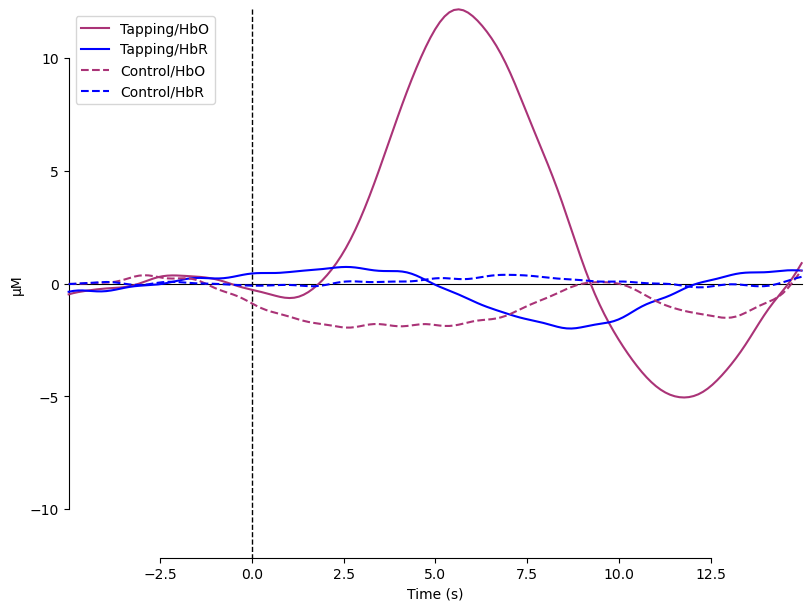

In [56]:
plot_mean(epochs)

# 1) Plot - Scalp map over gennemsnitlig hbo værdier over tid (Tapping)

No projector specified for this dataset. Please consider the method self.add_proj.


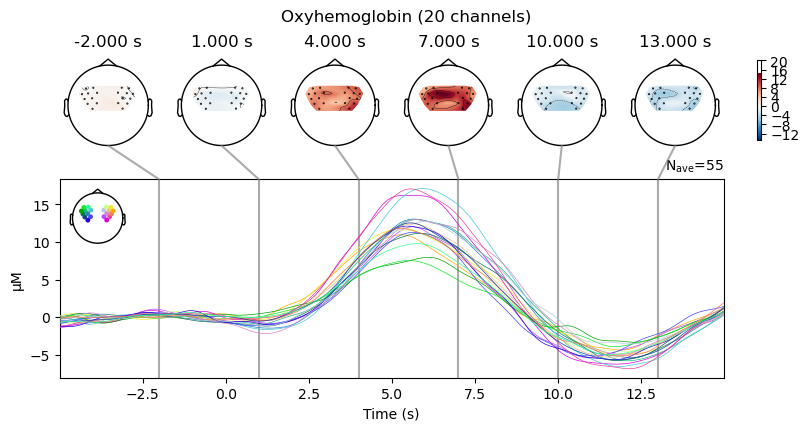

In [57]:
plot_scalp_mean(epochs)

# 3) Plot - Scalp map af aktivering af sensorer over tid opdelt i control/left/right og hbo/hbr


Tapping Left: Hbo


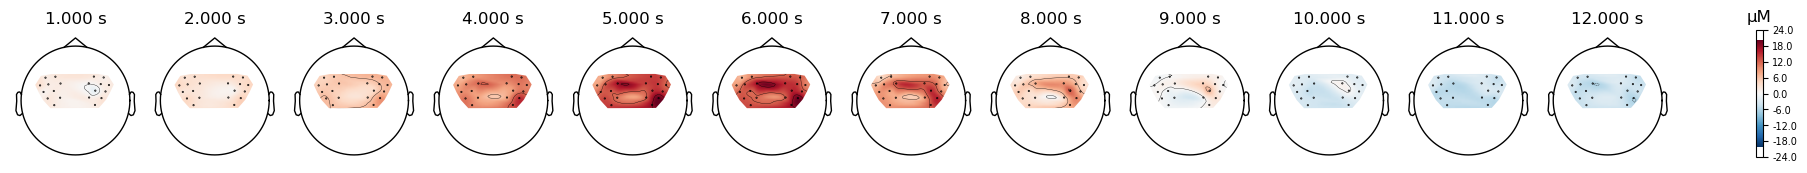

Tapping Left: Hbr


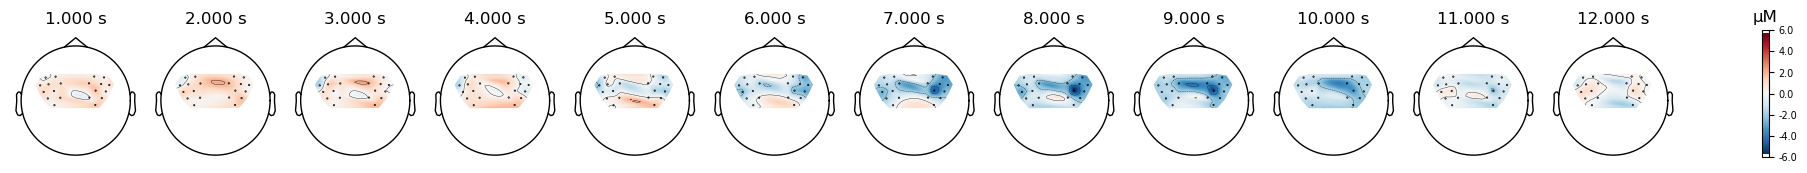


Tapping Right: Hbo


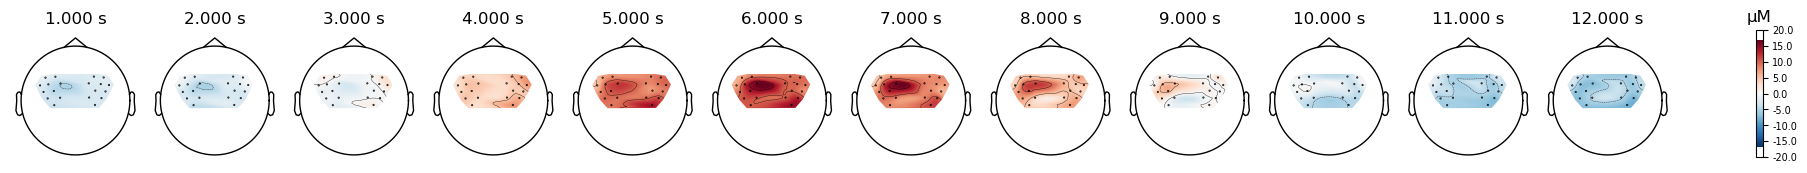

Tapping Right: Hbr


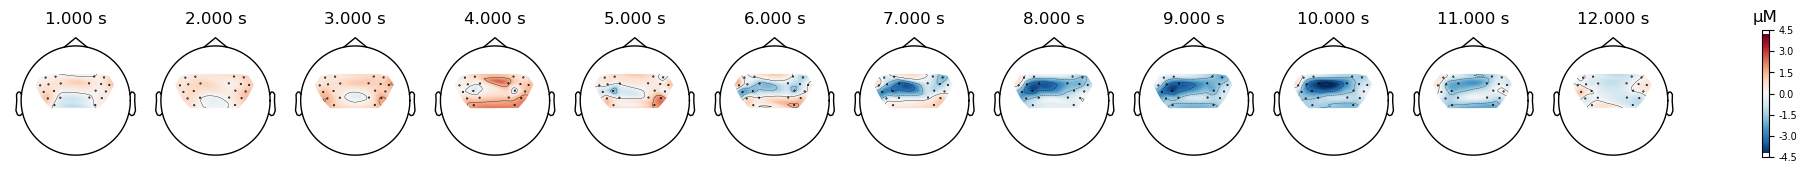


Control: Hbo


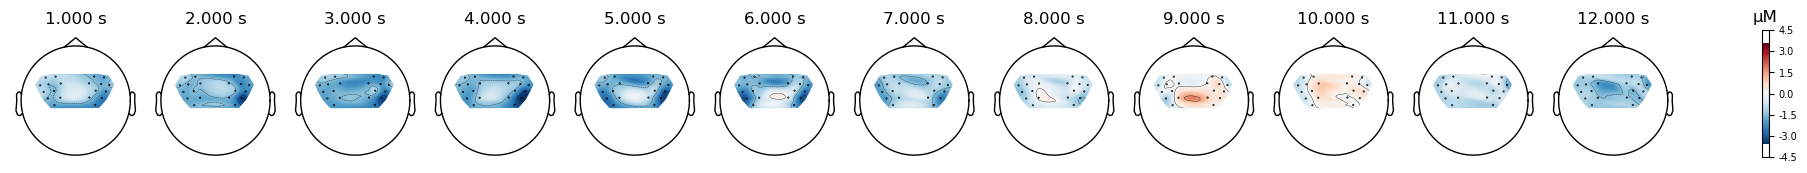

Control: Hbr


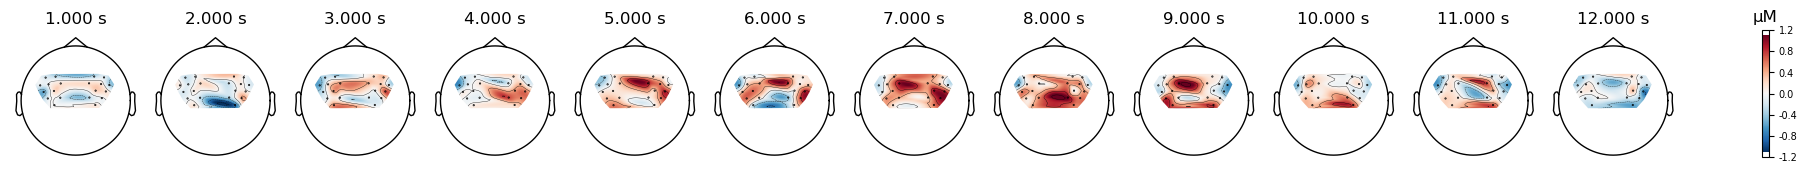

In [58]:
plot_scalp_map(epochs)

# Samme Scalp plots rekonstrureret med PCA 

In [59]:
def reconstruct_epochs_with_pca(epochs: mne.Epochs, n_components: int = 1) -> mne.Epochs:
    data = epochs.get_data()  # (n_epochs, n_channels, n_times)
    n_epochs, n_channels, n_times = data.shape

    X = data.transpose(0, 2, 1).reshape(-1, n_channels)  
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X) # (n_epochs*n_times, n_channels)
    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(X_scaled)                                   # (n_epochs*n_times, n_components)
    X_recon = pca.inverse_transform(scores)                         # (n_epochs*n_times, n_channels)

    data_recon = X_recon.reshape(n_epochs, n_times, n_channels).transpose(0, 2, 1)

    info = epochs.info.copy()
    events = epochs.events
    event_id = epochs.event_id
    tmin = epochs.tmin

    return EpochsArray(data_recon, info, events, tmin, event_id)

pca_epochs = reconstruct_epochs_with_pca(epochs, 2)

Not setting metadata
84 matching events found
No baseline correction applied
0 projection items activated


# Plot 1 rekonstrueret med 2 principal components

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


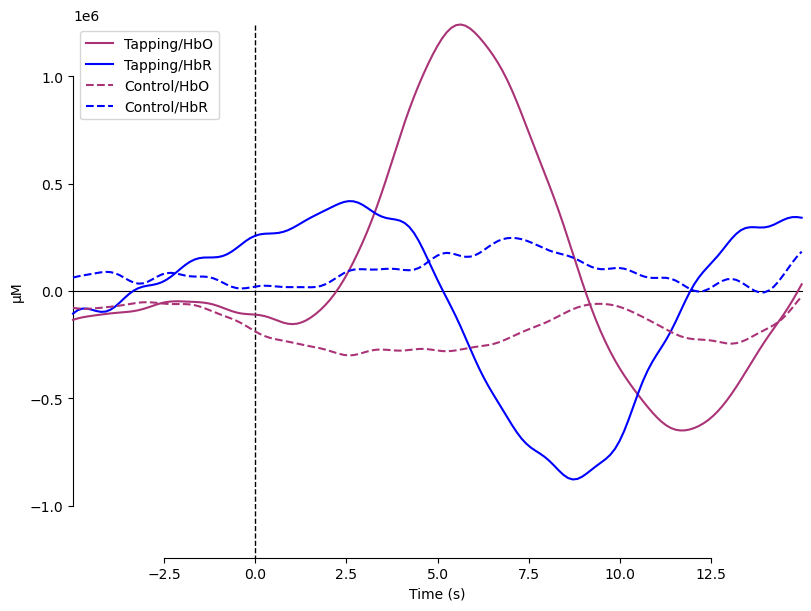

No projector specified for this dataset. Please consider the method self.add_proj.


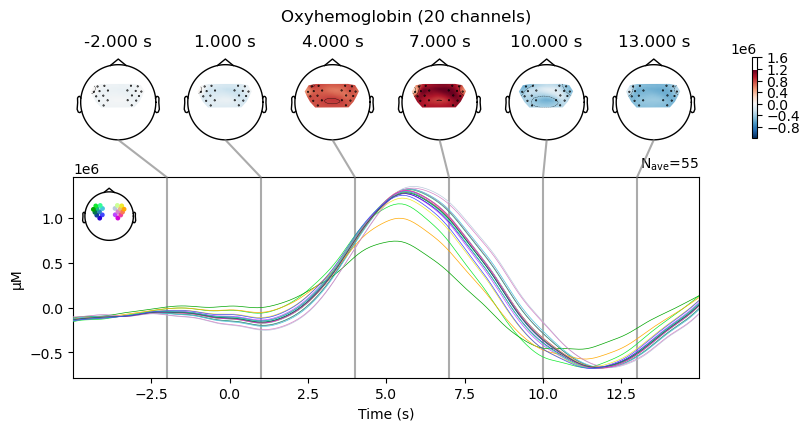


Tapping Left: Hbo


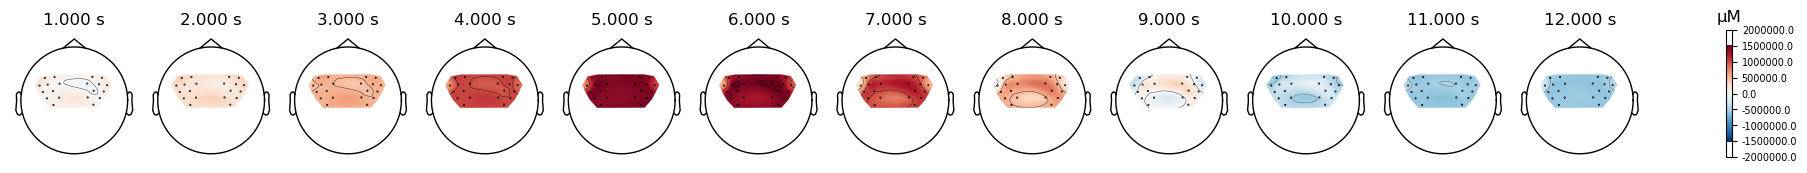

Tapping Left: Hbr


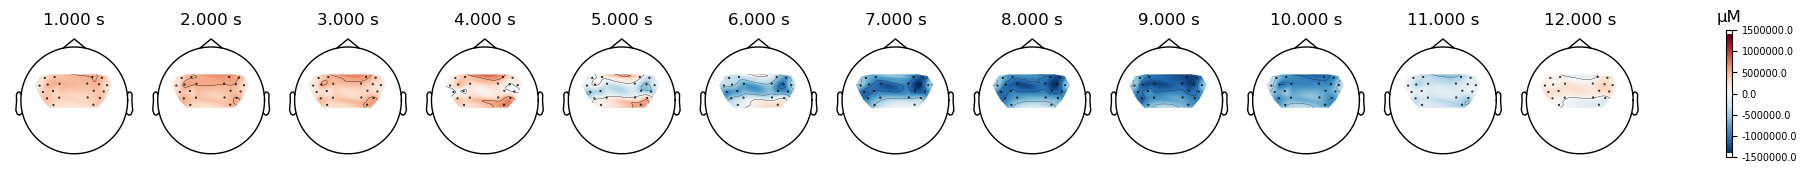


Tapping Right: Hbo


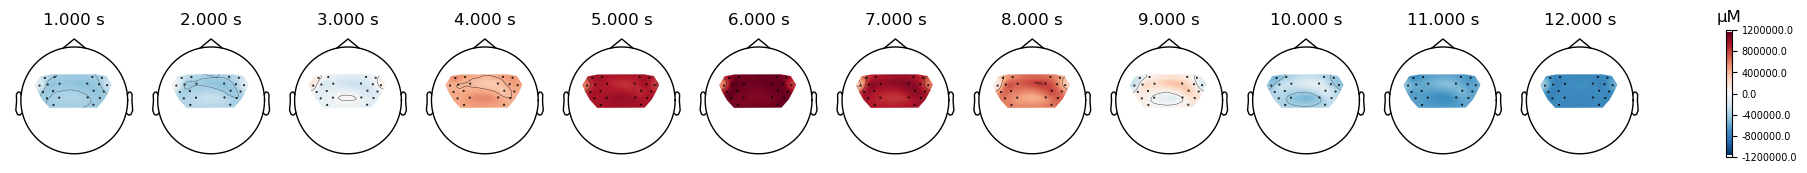

Tapping Right: Hbr


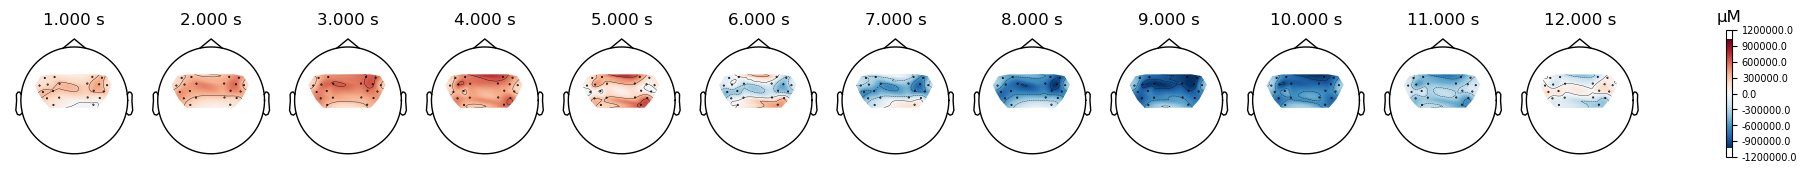


Control: Hbo


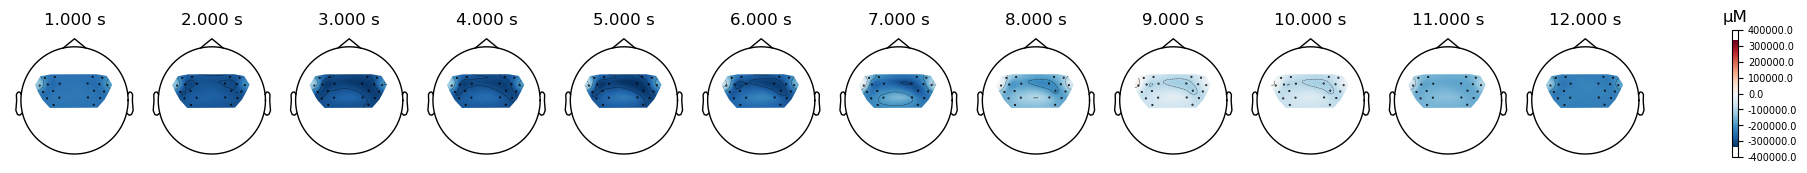

Control: Hbr


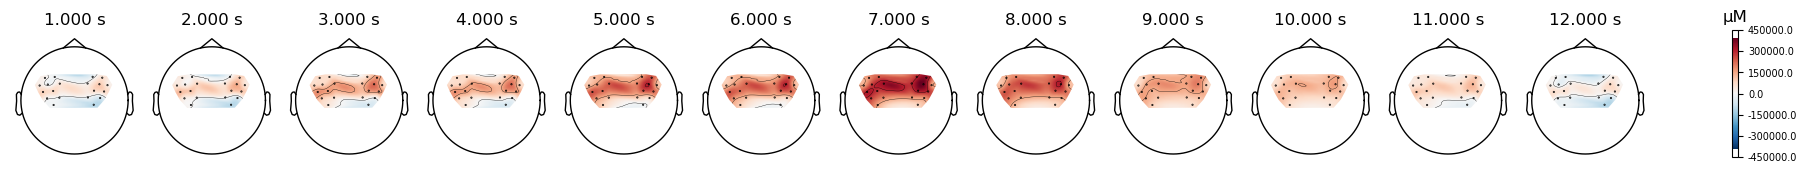

In [60]:
plot_mean(pca_epochs)
plot_scalp_mean(pca_epochs)
plot_scalp_map(pca_epochs)

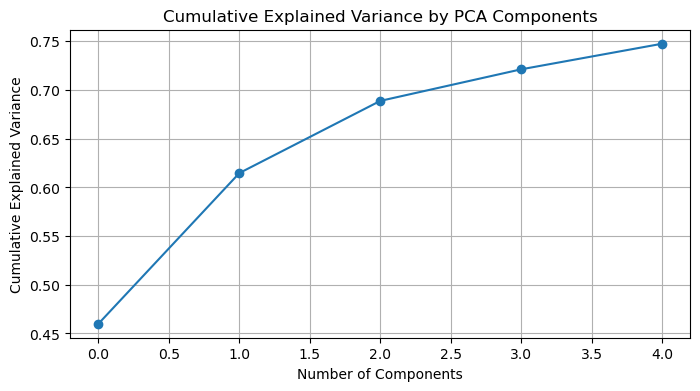

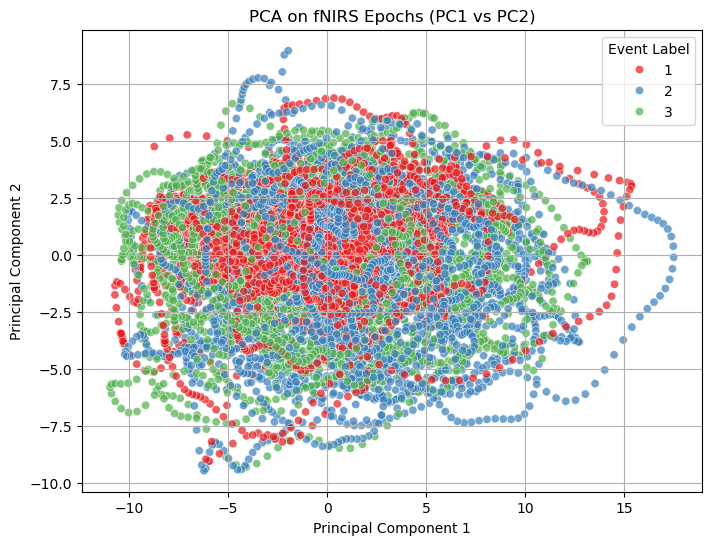

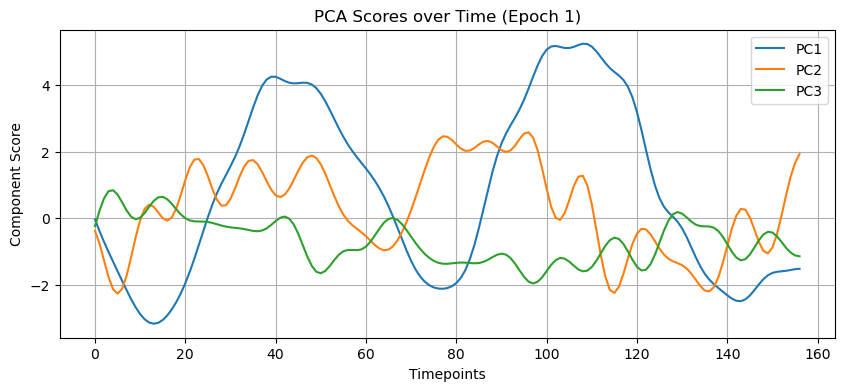

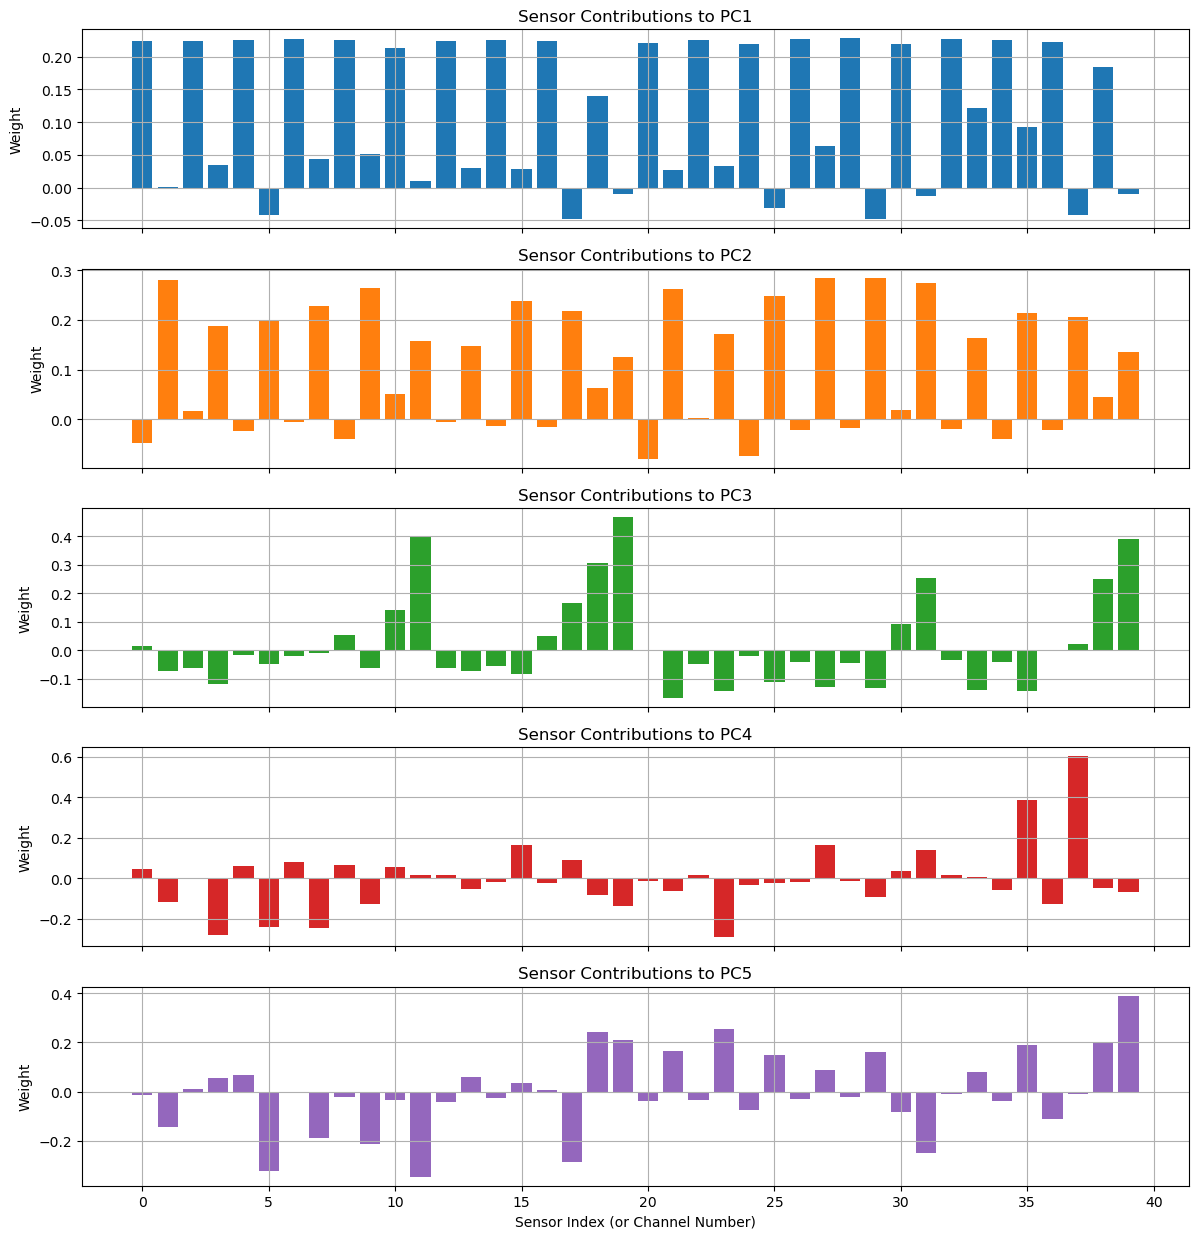

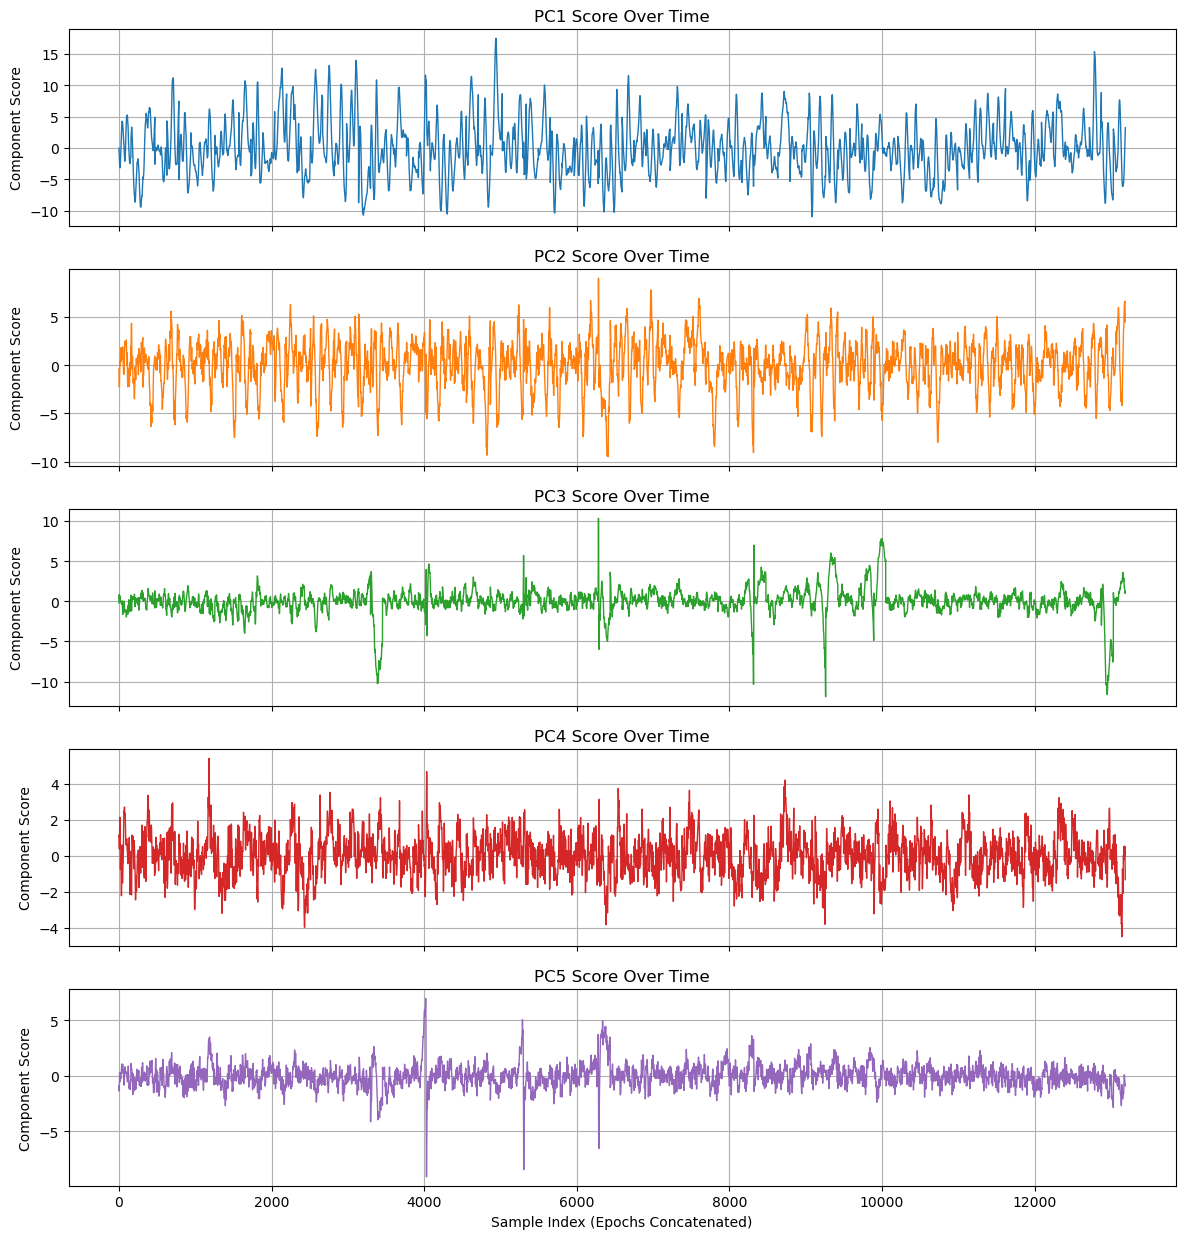

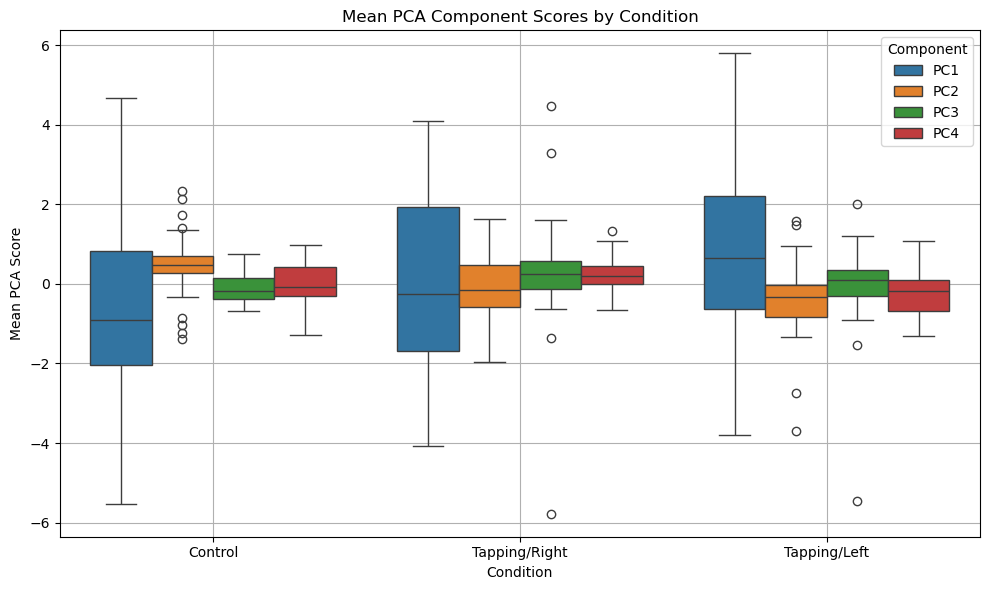

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mne.viz import plot_topomap

# --- Data Preparation ---
data = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)
n_epochs, n_channels, n_times = data.shape
labels = epochs.events[:, -1]  # use event labels

# Reshape for PCA (flatten time dimension)
X = data.transpose(0, 2, 1).reshape(-1, n_channels)  # shape: (n_epochs * n_times, n_channels)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Run PCA ---
n_components = 5
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# --- Create DataFrame for plotting ---
df_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(n_components)])
df_pca["label"] = np.repeat(labels, n_times)

# --- 1. Explained Variance Plot ---
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

# --- 2. 2D PCA Scatterplot (PC1 vs PC2) ---
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="label", alpha=0.7, palette="Set1")
plt.title("PCA on fNIRS Epochs (PC1 vs PC2)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.legend(title="Event Label")
plt.show()


# --- 3. Component Scores Over Time (1st Epoch) ---
scores_reshaped = X_pca.reshape(n_epochs, n_times, -1)
plt.figure(figsize=(10, 4))
for i in range(min(3, n_components)):
    plt.plot(scores_reshaped[0, :, i], label=f"PC{i+1}")
plt.title("PCA Scores over Time (Epoch 1)")
plt.xlabel("Timepoints")
plt.ylabel("Component Score")
plt.legend()
plt.grid(True)
plt.show()

# --- 4. Plot sensor contributions to first 5 PCs ---
n_plot_components = min(5, pca.components_.shape[0])

fig, axes = plt.subplots(n_plot_components, 1, figsize=(12, 2.5 * n_plot_components), sharex=True)

for i in range(n_plot_components):
    ax = axes[i]
    ax.bar(range(len(pca.components_[i])), pca.components_[i], color=f"C{i}")
    ax.set_title(f"Sensor Contributions to PC{i+1}")
    ax.set_ylabel("Weight")
    ax.grid(True)

axes[-1].set_xlabel("Sensor Index (or Channel Number)")
plt.tight_layout()
plt.show()


# --- 5. Separate plots for first 5 PCA components over the whole experiment ---
n_plot_components = min(5, n_components)

# Combine epochs for continuous timeline
all_scores_over_time = scores_reshaped[:, :, :n_plot_components].reshape(-1, n_plot_components)

# Plot each component in its own subplot
fig, axes = plt.subplots(n_plot_components, 1, figsize=(12, 2.5 * n_plot_components), sharex=True)

for i in range(n_plot_components):
    ax = axes[i]
    ax.plot(all_scores_over_time[:, i], color='C{}'.format(i), lw=1)
    ax.set_title(f"PC{i+1} Score Over Time")
    ax.set_ylabel("Component Score")
    ax.grid(True)

axes[-1].set_xlabel("Sample Index (Epochs Concatenated)")
plt.tight_layout()
plt.show()


# Invert event_id to get labels
event_id_inv = {v: k for k, v in epochs.event_id.items()}
labels = [event_id_inv[i] for i in epochs.events[:, 2]]

# Create wide-format DataFrame for first 4 PCs
pc_df = pd.DataFrame({
    'PC1': scores_reshaped[:, :, 0].mean(axis=1),
    'PC2': scores_reshaped[:, :, 1].mean(axis=1),
    'PC3': scores_reshaped[:, :, 2].mean(axis=1),
    'PC4': scores_reshaped[:, :, 3].mean(axis=1),
    'label': labels
})

# Melt to long-format for seaborn
pc_long = pc_df.melt(id_vars='label', var_name='PC', value_name='Score')

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=pc_long, x='label', y='Score', hue='PC')
plt.title("Mean PCA Component Scores by Condition")
plt.xlabel("Condition")
plt.ylabel("Mean PCA Score")
plt.legend(title="Component")
plt.grid(True)
plt.tight_layout()
plt.show()



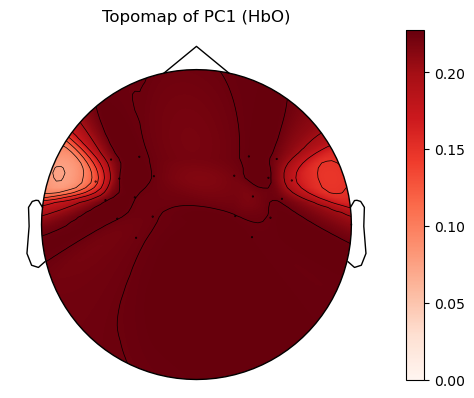

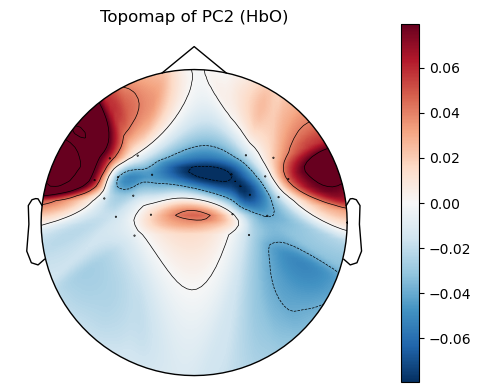

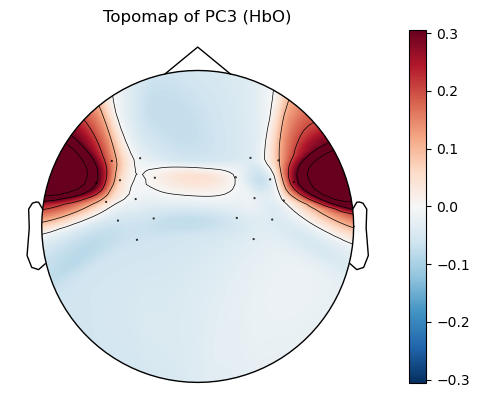

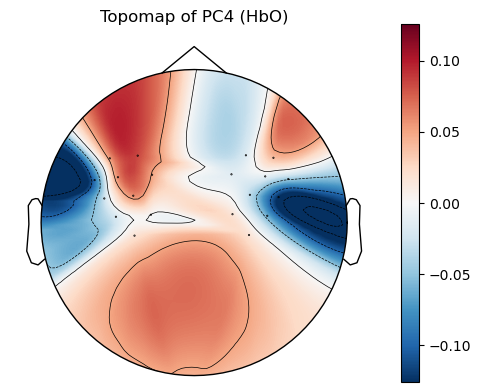

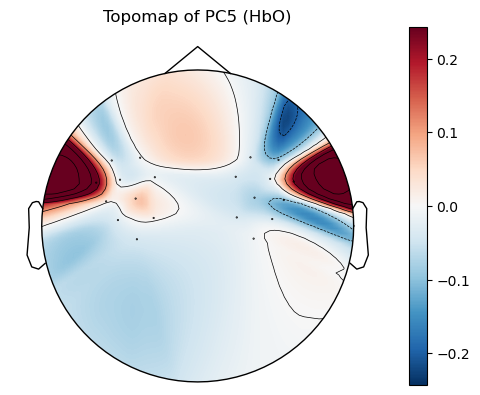

In [62]:
from mne.viz import plot_topomap
from mne import pick_types
import matplotlib.pyplot as plt

# Select HbO channels only
picks = pick_types(epochs.info, fnirs='hbo')

# Create Info object with just those channels
info_hbo = epochs.copy().pick(picks).info

# Get PCA components for those channels
components = pca.components_[:, picks]

# Plot each component separately with proper figure/axes handling
for i in range(5):  # First 5 PCs
    fig, ax = plt.subplots(figsize=(5, 4))
    im, _ = plot_topomap(components[i], info_hbo, axes=ax, show=False)
    ax.set_title(f"Topomap of PC{i+1} (HbO)")
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


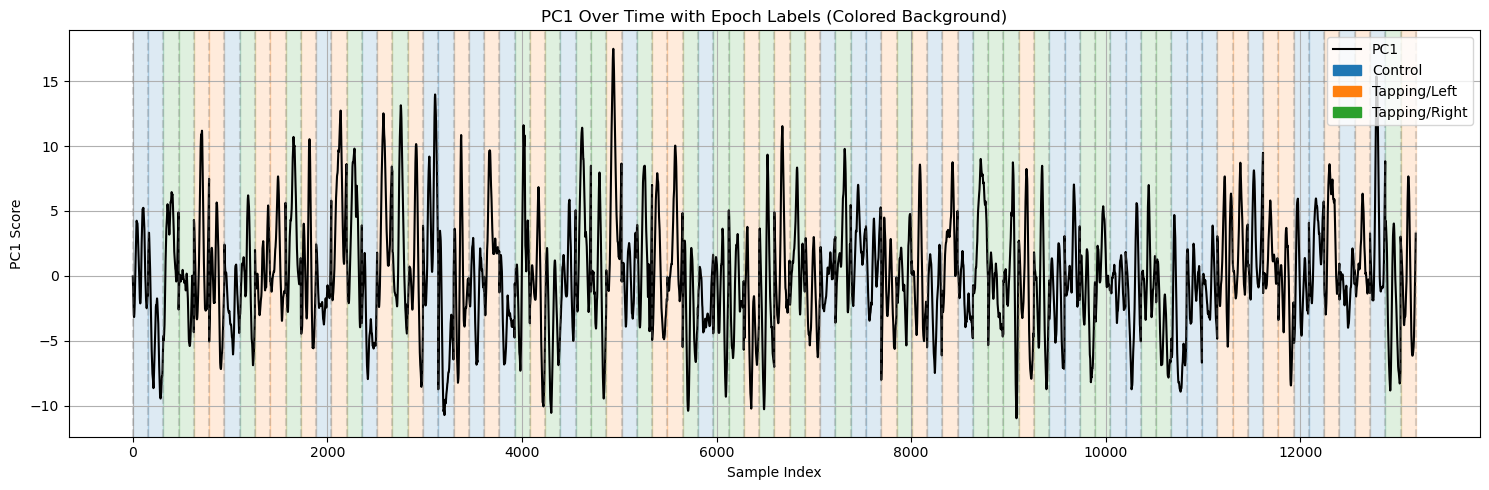

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare PC1 scores over the whole recording (flatten epochs and time)
# all_scores_over_time shape: (n_epochs * n_times, n_components)
pc1_scores = scores[:, 0]

n_epochs, n_times = scores_reshaped.shape[:2]
epoch_length = n_times

# Map event ids to labels
event_id_inv = {v: k for k, v in epochs.event_id.items()}
labels = [event_id_inv[i] for i in epochs.events[:, 2]]

# Get unique labels and assign colors
unique_labels = sorted(set(labels))
colors = plt.cm.tab10.colors  # Up to 10 distinct colors
label_color_map = {label: colors[i % len(colors)] for i, label in enumerate(unique_labels)}

plt.figure(figsize=(15, 5))

# Plot PC1 scores over time
plt.plot(pc1_scores, label='PC1', color='black')

# Shade epochs with corresponding colors
for i, label in enumerate(labels):
    start = i * epoch_length
    end = start + epoch_length
    plt.axvspan(start, end, color=label_color_map[label], alpha=0.15)

    # Optionally add vertical lines for epoch boundaries
    plt.axvline(start, color='gray', linestyle='--', alpha=0.3)

# Add final vertical line at end
plt.axvline(n_epochs * epoch_length, color='gray', linestyle='--', alpha=0.3)

plt.title("PC1 Over Time with Epoch Labels (Colored Background)")
plt.xlabel("Sample Index")
plt.ylabel("PC1 Score")
plt.grid(True)

# Create custom legend for epoch colors
from matplotlib.patches import Patch
legend_handles = [Patch(color=color, label=label) for label, color in label_color_map.items()]
plt.legend(handles=[plt.Line2D([], [], color='black', label='PC1')] + legend_handles, loc='upper right')

plt.tight_layout()
plt.show()
